# JMAIL Dataset: esplorazione raw e validazione preprocessing

Questo notebook documenta la prima verifica visuale del dataset JMAIL prima della fase di preprocessing e poi testa la pipeline di cleaning + feature engineering sul numero di sample specificato nella variabile `PROCESSING_SAMPLE_SIZE`.

La logica di preprocessing non viene implementata nel notebook: viene importata da `src/utils/data_processing.py`, così il notebook resta uno strumento di validazione e visualizzazione.

## 1. Setup

Carichiamo librerie, path di progetto e funzioni modulari. Il notebook usa il numero di sample specificato nella variabile `PROCESSING_SAMPLE_SIZE`; se vale `-1`, la pipeline viene eseguita su tutto il dataset.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.data_processing import run_processing_with_limit

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)

def project_path(env_key, default):
    value = Path(ENV.get(env_key, default))
    return value if value.is_absolute() else PROJECT_ROOT / value

PROCESSING_SAMPLE_SIZE = int(ENV.get("PROCESSING_SAMPLE_SIZE", "1000"))
SAMPLE_SIZE = PROCESSING_SAMPLE_SIZE if PROCESSING_SAMPLE_SIZE > 0 else 1000
PROCESSING_LIMIT = None if PROCESSING_SAMPLE_SIZE == -1 else PROCESSING_SAMPLE_SIZE
RAW_PATH = project_path("DATA_RAW_PATH", "data/raw/") / ENV.get("RAW_EMAILS_FILENAME", "jmail_emails.parquet")
PROCESSED_SAMPLE_PATH = project_path("DATA_PROCESSED_PATH", "data/processed/") / ENV.get(
    "PROCESSED_EMAILS_SAMPLE_FILENAME", "jmail_emails_processed_sample.parquet"
)
PROCESSING_METADATA_PATH = project_path("METADATA_PATH", "data/metadata/") / ENV.get(
    "PROCESSING_SAMPLE_METADATA_FILENAME", "jmail_processing_sample_metadata.json"
)
PROFILE_PATH = project_path("METADATA_PATH", "data/metadata/") / ENV.get("PROFILE_METADATA_FILENAME", "jmail_profile.json")
FIGURES_ROOT = project_path("FIGURES_PATH", "reports/figures/")
FIGURES_PATH = FIGURES_ROOT / ENV.get("NOTEBOOK_FIGURES_SUBDIR", "data_preprocessing_validation")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

RAW_NULL_RATIO_FIGURE = FIGURES_PATH / ENV.get("FIGURE_RAW_NULL_RATIO_FILENAME", "raw_null_ratio.png")
RAW_NULL_RATIO_DATA = FIGURES_PATH / ENV.get("FIGURE_RAW_NULL_RATIO_DATA_FILENAME", "raw_null_ratio.json")
RAW_OVERVIEW_FIGURE = FIGURES_PATH / ENV.get("FIGURE_RAW_OVERVIEW_FILENAME", "raw_dataset_overview.png")
RAW_OVERVIEW_DATA = FIGURES_PATH / ENV.get("FIGURE_RAW_OVERVIEW_DATA_FILENAME", "raw_dataset_overview.json")
PROCESSED_OVERVIEW_FIGURE = FIGURES_PATH / ENV.get("FIGURE_PROCESSED_OVERVIEW_FILENAME", "processed_dataset_overview.png")
PROCESSED_OVERVIEW_DATA = FIGURES_PATH / ENV.get("FIGURE_PROCESSED_OVERVIEW_DATA_FILENAME", "processed_dataset_overview.json")

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## 2. Caricamento sample raw

Prima del preprocessing osserviamo un estratto del Parquet raw. Usiamo PyArrow per leggere il numero di sample specificato nella variabile `PROCESSING_SAMPLE_SIZE`; se vale `-1`, per i grafici raw viene comunque usato un campione visuale limitato per evitare notebook troppo pesanti.

In [2]:
parquet_file = pq.ParquetFile(RAW_PATH)
first_batch = next(parquet_file.iter_batches(batch_size=SAMPLE_SIZE))
raw_sample = pa.Table.from_batches([first_batch]).to_pandas()

print(f"Righe sample raw: {len(raw_sample):,}")
print(f"Colonne sample raw: {raw_sample.shape[1]}")
raw_sample.head(3)

Righe sample raw: 1,000
Colonne sample raw: 19


,id,doc_id,message_index,sender,subject,to_recipients,cc_recipients,bcc_recipients,sent_at,content_markdown,content_html,attachments,account_email,email_drop_id,folder_path,is_promotional,release_batch,epstein_is_sender,all_participants
0,000973eb49f43cdcead0876fb2de6989,9ed3cf0dc144d9ef7df792bb2fa74c52,0,Houzz Updates <updates@houzz.com>,Color of the Week | 1940s Ranch Redo | Your July Home Checklist,"[""<jeeproject@yahoo.com>""]",[],[],2015-07-01T13:26:22.000Z,"To-Dos: Your July Home Checklist\n\nCrank up the ice cream maker, hang up the hammock and raise the outdoor umbrella...","<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 Transitional//EN"" ""http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional....",0,jeeproject@yahoo.com,yahoo_2,Inbox,True,1,False,"houzz updates <updates@houzz.com> [""<jeeproject@yahoo.com>""] [] []"
1,000f08c9cb90acbc5332fcbb1915f985,584bc87a2226599969664a61fd4e39fe,0,Spotify <hello@spotify.com>,"Upcoming shows near New York: Michael Feinstein, Boston Pops Orchestra and more","[""<jeeproject@yahoo.com>""]",[],[],2018-09-26T02:00:00.000Z,"Upcoming concerts near you by artists you love.\n\n *Michael Feinstein*\n\n Sun, Oct 28\n\n New Jersey ...","<!DOCTYPE html><html xmlns=""http://www.w3.org/1999/xhtml"" style=""margin: 0; padding: 0""><head><meta charset=""utf-8"" ...",0,jeeproject@yahoo.com,yahoo_2,Inbox,True,1,False,"spotify <hello@spotify.com> [""<jeeproject@yahoo.com>""] [] []"
2,000fa4d83ae293b30ed3571c9ea2fd77,905350832d97dc3675bfed84993cd746,0,jeffrey E. <jeevacation@gmail.com>,Re: Title and subtitle,"[""Ehud Barak <ehbarak1@gmail.com>""]",[],NaN,2015-05-07T07:07:33.000Z,"prefer OUR COUNTRY , MY LIFE or MOMENTS","<div dir=""ltr"">prefer OUR COUNTRY , MY LIFE or MOMENTS<br>",0,ehbarak1@gmail.com,ehud_ddos_dropsite_1,NaN,False,8,True,"jeffrey e. <jeevacation@gmail.com> [""ehud barak <ehbarak1@gmail.com>""] []"


## 3. Struttura e copertura del dataset raw

Questa sezione mostra schema e valori mancanti prima di qualsiasi filtro. È utile per capire quali colonne sono affidabili e quali sono poco coperte.

In [3]:
with PROFILE_PATH.open(encoding="utf-8") as file_handle:
    profile = json.load(file_handle)

profile_summary = pd.DataFrame(profile["columns"])[["name", "type", "null_count", "null_ratio", "non_null_count"]]
profile_summary.sort_values("null_ratio", ascending=False).head(10)

,name,type,null_count,null_ratio,non_null_count
10,content_html,string,1767731,0.990996,16061
14,folder_path,string,1766344,0.990219,17448
12,account_email,string,1755546,0.984165,28246
4,subject,string,458403,0.256982,1325389
3,sender,string,127331,0.071382,1656461
8,sent_at,string,5032,0.002821,1778760
17,epstein_is_sender,bool,1779,0.000997,1782013
7,bcc_recipients,string,1059,0.000594,1782733
9,content_markdown,string,501,0.000281,1783291
15,is_promotional,bool,7,0.000004,1783785


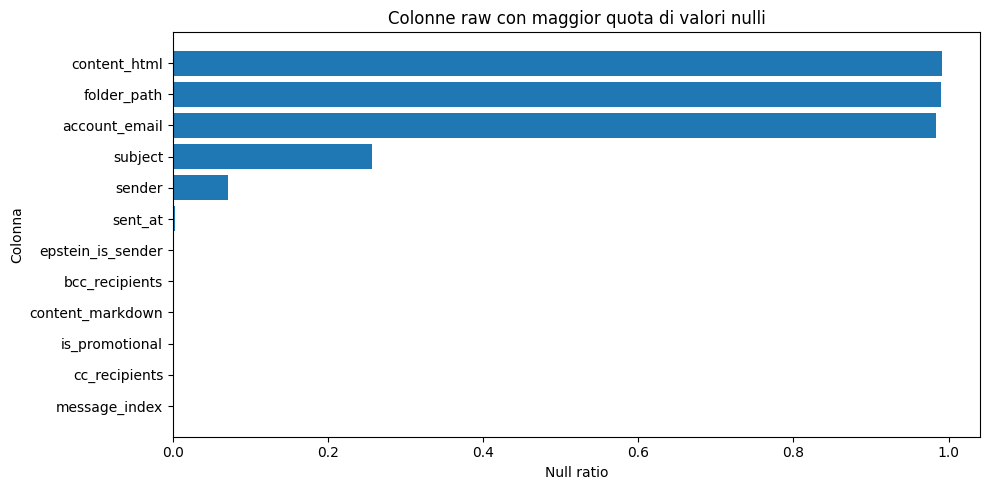

In [4]:
raw_null_ratio_fig, ax = plt.subplots(figsize=(10, 5))
plot_data = profile_summary.sort_values("null_ratio", ascending=False).head(12)
ax.barh(plot_data["name"], plot_data["null_ratio"])
ax.invert_yaxis()
ax.set_title("Colonne raw con maggior quota di valori nulli")
ax.set_xlabel("Null ratio")
ax.set_ylabel("Colonna")
raw_null_ratio_fig.tight_layout()
plt.show()

In [5]:
raw_null_ratio_payload = {
    "title": "Colonne raw con maggior quota di valori nulli",
    "x_label": "Null ratio",
    "y_label": "Colonna",
    "data": plot_data[["name", "null_ratio", "null_count", "non_null_count"]].to_dict(orient="records"),
}
RAW_NULL_RATIO_DATA.write_text(json.dumps(raw_null_ratio_payload, indent=2, ensure_ascii=False), encoding="utf-8")
raw_null_ratio_fig.savefig(RAW_NULL_RATIO_FIGURE, dpi=160, bbox_inches="tight")
print(f"Figura salvata in: {RAW_NULL_RATIO_FIGURE}")
print(f"Dati figura salvati in: {RAW_NULL_RATIO_DATA}")

Figura salvata in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/raw_null_ratio.png
Dati figura salvati in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/raw_null_ratio.json


## 4. Grafici esplorativi prima del preprocessing

I grafici seguenti descrivono il dataset raw prima della pulizia: presenza di email promozionali, lunghezze testuali, allegati e distribuzione temporale grezza.

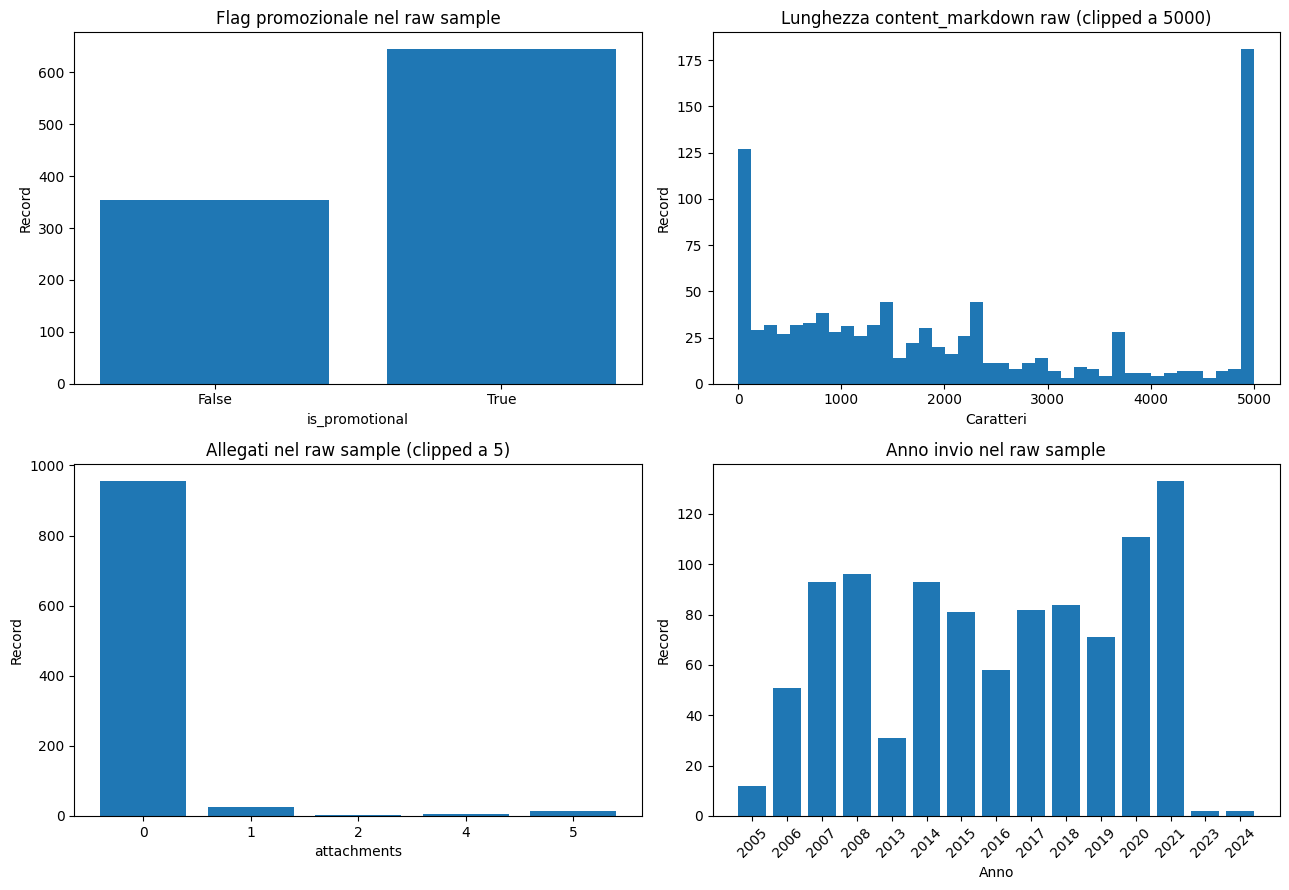

In [6]:
raw_plot = raw_sample.copy()
raw_plot["subject_length_raw"] = raw_plot["subject"].fillna("").astype(str).str.len()
raw_plot["content_length_raw"] = raw_plot["content_markdown"].fillna("").astype(str).str.len()
raw_plot["sent_at_datetime_raw"] = pd.to_datetime(raw_plot["sent_at"], errors="coerce", utc=True)

raw_overview_fig, axes = plt.subplots(2, 2, figsize=(13, 9))

promo_counts = raw_plot["is_promotional"].fillna("unknown").astype(str).value_counts().sort_index()
axes[0, 0].bar(promo_counts.index, promo_counts.values)
axes[0, 0].set_title("Flag promozionale nel raw sample")
axes[0, 0].set_xlabel("is_promotional")
axes[0, 0].set_ylabel("Record")

axes[0, 1].hist(raw_plot["content_length_raw"].clip(upper=5000), bins=40)
axes[0, 1].set_title("Lunghezza content_markdown raw (clipped a 5000)")
axes[0, 1].set_xlabel("Caratteri")
axes[0, 1].set_ylabel("Record")

attachment_counts = raw_plot["attachments"].fillna(0).clip(upper=5).value_counts().sort_index()
axes[1, 0].bar(attachment_counts.index.astype(str), attachment_counts.values)
axes[1, 0].set_title("Allegati nel raw sample (clipped a 5)")
axes[1, 0].set_xlabel("attachments")
axes[1, 0].set_ylabel("Record")

sent_year_counts = raw_plot["sent_at_datetime_raw"].dt.year.dropna().astype(int).value_counts().sort_index()
axes[1, 1].bar(sent_year_counts.index.astype(str), sent_year_counts.values)
axes[1, 1].set_title("Anno invio nel raw sample")
axes[1, 1].set_xlabel("Anno")
axes[1, 1].set_ylabel("Record")
axes[1, 1].tick_params(axis="x", rotation=45)

raw_overview_fig.tight_layout()
plt.show()

In [7]:
raw_overview_payload = {
    "title": "Raw dataset overview",
    "sample_size": SAMPLE_SIZE,
    "charts": {
        "is_promotional_counts": promo_counts.rename_axis("is_promotional").reset_index(name="count").to_dict(orient="records"),
        "content_length_raw_histogram": {
            "clip_upper": 5000,
            "bin_count": 40,
            "values": raw_plot["content_length_raw"].clip(upper=5000).tolist(),
        },
        "attachment_counts_clipped": attachment_counts.rename_axis("attachments_clipped").reset_index(name="count").to_dict(orient="records"),
        "sent_year_counts": sent_year_counts.rename_axis("sent_year").reset_index(name="count").to_dict(orient="records"),
    },
}
RAW_OVERVIEW_DATA.write_text(json.dumps(raw_overview_payload, indent=2, ensure_ascii=False), encoding="utf-8")
raw_overview_fig.savefig(RAW_OVERVIEW_FIGURE, dpi=160, bbox_inches="tight")
print(f"Figura salvata in: {RAW_OVERVIEW_FIGURE}")
print(f"Dati figura salvati in: {RAW_OVERVIEW_DATA}")

Figura salvata in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/raw_dataset_overview.png
Dati figura salvati in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/raw_dataset_overview.json


## 5. Esecuzione pipeline su sample

Eseguiamo la pipeline approvata usando il valore di `PROCESSING_SAMPLE_SIZE`. Se il valore è positivo, l'output è il processed sample; se vale `-1`, l'output è il processed completo.

Nota sulle censure: la pipeline non modifica le parti censurate; crea solo il flag `has_redaction`.

In [8]:
processing_result = run_processing_with_limit(env_file=ENV_PATH, limit=PROCESSING_LIMIT)
processing_result

{'raw_path': '/home/suga/Workspace/Projects/pizza-cluster/data/raw/jmail_emails.parquet',
 'processed_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet',
 'metadata_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/metadata/jmail_processing_sample_metadata.json',
 'input_rows': 1000,
 'output_rows': 355,
 'removed_promotional_rows': 645,
 'removed_empty_text_rows': 0}

## 6. Lettura processed sample e metadata

Carichiamo il sample processato e i metadata generati dalla pipeline per verificare righe, colonne e scelte applicate.

In [9]:
processed_sample = pd.read_parquet(PROCESSED_SAMPLE_PATH)
with PROCESSING_METADATA_PATH.open(encoding="utf-8") as file_handle:
    processing_metadata = json.load(file_handle)

pd.DataFrame([processing_metadata])[[
    "execution_mode",
    "input_limit",
    "input_rows",
    "output_rows",
    "removed_promotional_rows",
    "removed_empty_text_rows",
]]

,execution_mode,input_limit,input_rows,output_rows,removed_promotional_rows,removed_empty_text_rows
0,sample,1000,1000,355,645,0


In [10]:
print(f"Colonne processed: {processed_sample.shape[1]}")
processed_sample[[
    "id",
    "subject_clean",
    "combined_text_length",
    "has_redaction",
    "has_attachments",
    "recipient_count_estimate",
    "sent_year",
]].head(5)

Colonne processed: 31


,id,subject_clean,combined_text_length,has_redaction,has_attachments,recipient_count_estimate,sent_year
0,000fa4d83ae293b30ed3571c9ea2fd77,Re: Title and subtitle,63,False,False,2,2015
1,001612df62eb14194162f0a366793927,Re: Barbro Ehnbom: SALSS 2006,715,False,False,3,2006
2,001df92b110e9da90631a66cf97a0a11,Re:,459,False,False,3,2007
3,0036be5386133888b4201acacd0d6178,Infographic: 5 Ways to Take Center Stage at Work,3916,False,False,3,2017
4,0037a69505ae78dfacfebd97260f5325,Don't Miss Our Biggest Sale! Save 50% for 26 Weeks on a Times Subscription.,1652,False,False,3,2014


## 7. Grafici dopo preprocessing

Questi grafici controllano l'effetto della pipeline: righe filtrate, lunghezze testo processato, censure rilevate e destinatari stimati.

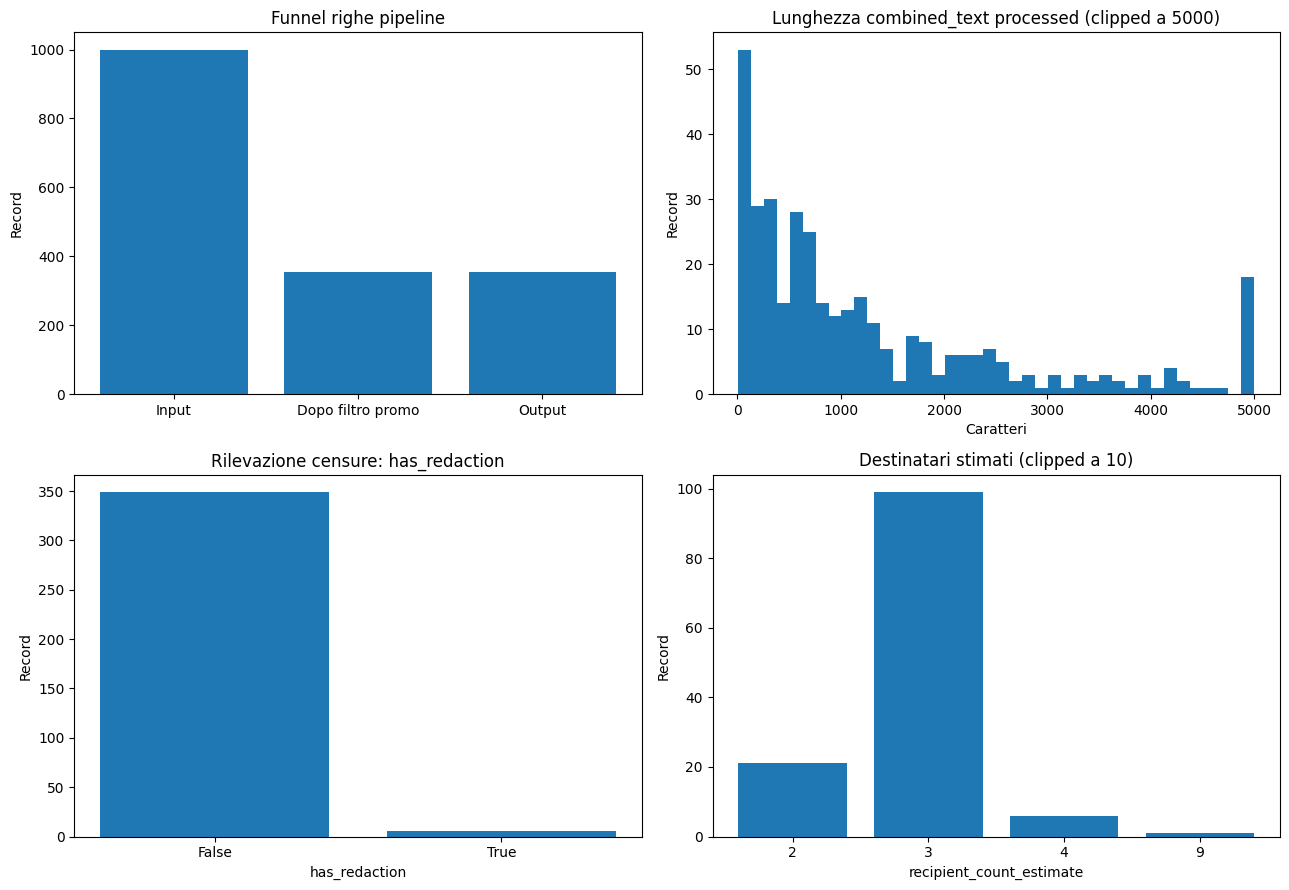

In [11]:
processed_overview_fig, axes = plt.subplots(2, 2, figsize=(13, 9))

funnel_labels = ["Input", "Dopo filtro promo", "Output"]
funnel_values = [
    processing_metadata["input_rows"],
    processing_metadata["after_promotional_filter_rows"],
    processing_metadata["output_rows"],
]
axes[0, 0].bar(funnel_labels, funnel_values)
axes[0, 0].set_title("Funnel righe pipeline")
axes[0, 0].set_ylabel("Record")

axes[0, 1].hist(processed_sample["combined_text_length"].clip(upper=5000), bins=40)
axes[0, 1].set_title("Lunghezza combined_text processed (clipped a 5000)")
axes[0, 1].set_xlabel("Caratteri")
axes[0, 1].set_ylabel("Record")

redaction_counts = processed_sample["has_redaction"].value_counts().sort_index()
axes[1, 0].bar(redaction_counts.index.astype(str), redaction_counts.values)
axes[1, 0].set_title("Rilevazione censure: has_redaction")
axes[1, 0].set_xlabel("has_redaction")
axes[1, 0].set_ylabel("Record")

recipient_counts = processed_sample["recipient_count_estimate"].clip(upper=10).value_counts().sort_index()
axes[1, 1].bar(recipient_counts.index.astype(str), recipient_counts.values)
axes[1, 1].set_title("Destinatari stimati (clipped a 10)")
axes[1, 1].set_xlabel("recipient_count_estimate")
axes[1, 1].set_ylabel("Record")

processed_overview_fig.tight_layout()
plt.show()

In [12]:
processed_overview_payload = {
    "title": "Processed dataset overview",
    "sample_size": SAMPLE_SIZE,
    "charts": {
        "pipeline_funnel": [
            {"stage": stage, "count": int(count)} for stage, count in zip(funnel_labels, funnel_values)
        ],
        "combined_text_length_histogram": {
            "clip_upper": 5000,
            "bin_count": 40,
            "values": processed_sample["combined_text_length"].clip(upper=5000).astype(int).tolist(),
        },
        "has_redaction_counts": redaction_counts.rename_axis("has_redaction").reset_index(name="count").to_dict(orient="records"),
        "recipient_count_estimate_clipped": recipient_counts.rename_axis("recipient_count_estimate_clipped").reset_index(name="count").to_dict(orient="records"),
    },
}
PROCESSED_OVERVIEW_DATA.write_text(json.dumps(processed_overview_payload, indent=2, ensure_ascii=False), encoding="utf-8")
processed_overview_fig.savefig(PROCESSED_OVERVIEW_FIGURE, dpi=160, bbox_inches="tight")
print(f"Figura salvata in: {PROCESSED_OVERVIEW_FIGURE}")
print(f"Dati figura salvati in: {PROCESSED_OVERVIEW_DATA}")

Figura salvata in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/processed_dataset_overview.png
Dati figura salvati in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/data_preprocessing_validation/processed_dataset_overview.json


## 8. Controlli finali

Questi controlli non sostituiscono i test unitari, ma rendono esplicite alcune aspettative minime del notebook: output non vuoto, feature presenti e censure solo segnalate.

In [13]:
required_columns = {
    "combined_text",
    "combined_text_length",
    "has_redaction",
    "has_attachments",
    "recipient_count_estimate",
    "sent_year",
    "sent_month",
    "sent_dayofweek",
}
missing_columns = required_columns - set(processed_sample.columns)

assert processed_sample.shape[0] > 0, "Il processed sample non deve essere vuoto."
assert not missing_columns, f"Colonne mancanti: {missing_columns}"
assert processing_metadata["execution_mode"] == "sample"

print("Controlli notebook completati.")
print(f"Righe output: {processed_sample.shape[0]}")
print(f"Feature presenti: {len(required_columns)} su {len(required_columns)}")

Controlli notebook completati.
Righe output: 355
Feature presenti: 8 su 8


## 9. Conclusioni operative

Il sample configurato conferma l'impatto del filtro promozionale e che il testo utile rimane disponibile dopo il preprocessing. La feature `has_redaction` segnala i casi da trattare con attenzione in una fase successiva, senza alterare il contenuto testuale.

La prossima fase può usare questo notebook come controllo visuale prima di passare a embedding e clustering sul processed dataset.